# 01 · Análisis Exploratorio de Datos (EDA)

**Proyecto:** Detección y clasificación de fracturas óseas en radiografías
**Fase 1 (CRISP-DM: *Data Understanding*)** · Aprendizaje Computacional · U. de Córdoba

Este notebook explora el dataset **Bone Fracture Multi-Region X-ray Data**
(Kaggle, autor `bmadushanirodrigo`, licencia ODC-By v1.0), responde a las
preguntas que exige la guía del proyecto (¿está balanceado?, ¿hay corruptas o
repetidas?, ¿qué sesgos hay?) y documenta la **limpieza** que prepara los datos
para el modelado (Fase 2).

> **Entorno:** ejecútalo en el venv del proyecto (Python 3.11/3.12). Si solo
> tienes Python 3.14, crea el entorno como indica el `README.md` antes de correr.

## Flujo de datos del proyecto
```
archive/ (zip manual)  ─┐
                         ├─ src/prepare_data.py  →  data/raw/        split OFICIAL (con duplicados y fuga)
kagglehub (automático) ─┘       └─ src/deduplicate_split.py → data/processed/  split LIMPIO ← se entrena aquí
```

> La celda siguiente descarga el dataset automáticamente vía `kagglehub` si
> `data/raw/` no existe. Requiere credenciales Kaggle configuradas o la carpeta
> `archive/` presente (descarga manual).

## 0 · Configuración

In [1]:
# ── Setup Colab (se omite automáticamente si se ejecuta en local) ─────────────
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL  = "https://github.com/stevenrq/fracturas-rayos-x.git"
    REPO_DIR  = Path("/content/fracturas-rayos-x")
    if not REPO_DIR.exists():
        import subprocess
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR / "notebooks")   # todos los paths "../" del notebook quedan válidos
    print(f"✓ CWD: {os.getcwd()}")
else:
    print(f"✓ Local — CWD: {os.getcwd()}")

✓ CWD: /content/fracturas-rayos-x/notebooks


In [2]:
# Adquisición de datos (idempotente: se omite si data/raw/ ya existe)
import subprocess, sys
from pathlib import Path

_raw = Path("../data/raw")
_has_raw = _raw.exists() and any(
    p.is_file()
    for p in _raw.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

if not _has_raw:
    print("data/raw/ no encontrado — ejecutando src/prepare_data.py …")
    result = subprocess.run(
        [sys.executable, "../src/prepare_data.py"],
        capture_output=True, text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr, file=sys.stderr)
        raise RuntimeError(
            "prepare_data.py falló. Revisa las credenciales de Kaggle:\n"
            "https://github.com/Kaggle/kagglehub#authentication\n"
            "O descarga manualmente y descomprime en archive/."
        )
    print("✓ data/raw/ listo.")
else:
    print("✓ data/raw/ ya existe, omitiendo descarga.")

data/raw/ no encontrado — ejecutando src/prepare_data.py …
Descargando dataset desde Kaggle vía kagglehub …
Extracting files...
  Descargado en: /root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2
  Raíz del dataset detectada: /root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification
Copiando /root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification
  -> /content/fracturas-rayos-x/data/raw

  train  not fractured -> 0_normal      4640 imágenes
  train  fractured     -> 1_fracture    4606 imágenes
  val    not fractured -> 0_normal       492 imágenes
  val    fractured     -> 1_fracture     337 imágenes
  test   not fractured -> 0_normal       268 imágenes
  test   fractured     -> 1_fracture     238 imágenes

Procesadas 10581 imágen

In [3]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

RAW = Path("../data/raw")          # split oficial de Kaggle (renombrado a 0_normal/1_fracture)
PROC = Path("../data/processed")   # split limpio (dedup + sin fuga)
FIGS = Path("../reports/figures"); FIGS.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]
CLASSES = ["0_normal", "1_fracture"]
IMG_EXTS = {".jpg", ".jpeg", ".png"}

def list_images(folder: Path):
    if not folder.exists():
        return []
    return [p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS]

def counts_table(root: Path) -> pd.DataFrame:
    rows = {c: {s: len(list_images(root / s / c)) for s in SPLITS} for c in CLASSES}
    df = pd.DataFrame(rows).T
    df["total"] = df.sum(axis=1)
    df.loc["total"] = df.sum(axis=0)
    return df

## 1 · Conteo por clase y split — split **oficial** (`data/raw`)

Split OFICIAL (data/raw):


,train,val,test,total
0_normal,4640,492,268,5400
1_fracture,4606,337,238,5181
total,9246,829,506,10581


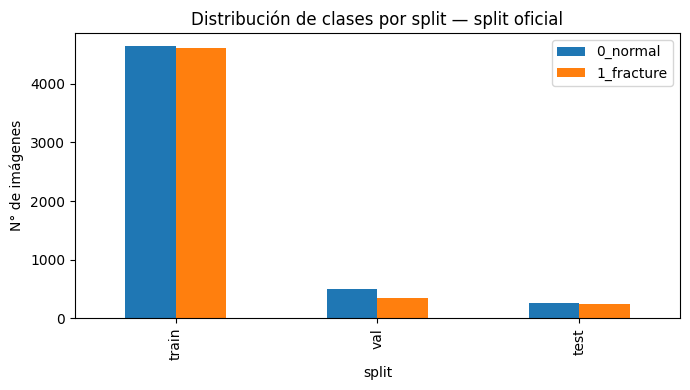

In [4]:
df_raw = counts_table(RAW)
print("Split OFICIAL (data/raw):")
display(df_raw)

ax = df_raw.loc[CLASSES, SPLITS].T.plot(kind="bar", figsize=(7, 4))
ax.set_title("Distribución de clases por split — split oficial")
ax.set_ylabel("N° de imágenes"); ax.set_xlabel("split")
plt.tight_layout(); plt.savefig(FIGS / "distribucion_clases_oficial.png", dpi=120, bbox_inches="tight")
plt.show()

**Observación (valores reales medidos):** el split oficial tiene **10 581 imágenes**.

| split | 0_normal | 1_fracture | total |
|---|---|---|---|
| train | 4640 | 4606 | 9246 |
| val   | 492  | 337  | 829  |
| test  | 268  | 238  | 506  |

- En **train** las clases están casi perfectamente balanceadas (≈50/50) → los
  pesos de clase serán ≈ 1.0.
- En **val** hay un ligero sesgo hacia *normal* (≈59/41). No afecta al
  entrenamiento, pero hay que tenerlo en cuenta al leer sus métricas.

## 2 · Formato, canales y resolución

Las redes preentrenadas esperan **3 canales (RGB)** y un tamaño fijo. Verificamos
modos de color, extensiones, resoluciones y posibles archivos corruptos.

Modos de color: {'RGB': 10041, 'L': 511, 'P': 9, 'RGBA': 20}
Extensiones   : {'.jpg': 10331, '.png': 191, '.jpeg': 59}
Corruptas     : 0
Ancho  min/mediana/p95/max: 100/224/750/4232
Alto   min/mediana/p95/max: 100/224/1024/5823
Exactamente 224x224: 9512/10581 (89.9%)


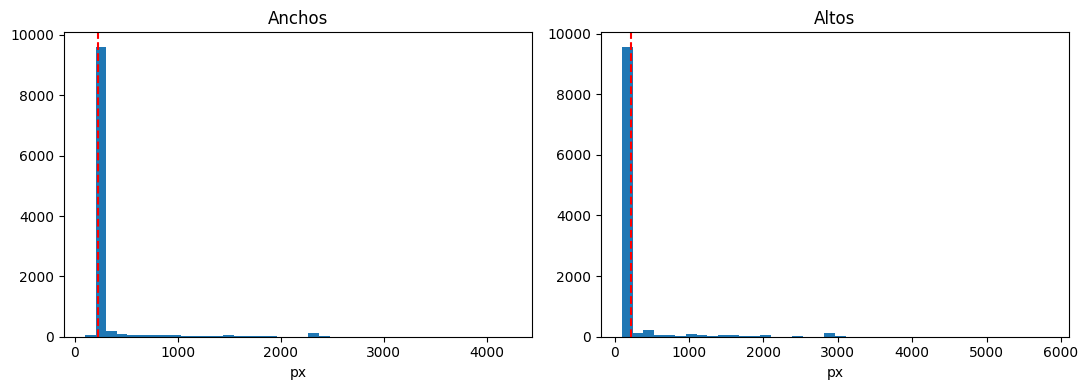

In [5]:
modes, exts = Counter(), Counter()
widths, heights, corrupt = [], [], []
for s in SPLITS:
    for c in CLASSES:
        for p in list_images(RAW / s / c):
            exts[p.suffix.lower()] += 1
            try:
                with Image.open(p) as im:
                    im.verify()
                with Image.open(p) as im:
                    modes[im.mode] += 1
                    widths.append(im.size[0]); heights.append(im.size[1])
            except Exception as e:
                corrupt.append((str(p), str(e)))

print("Modos de color:", dict(modes))
print("Extensiones   :", dict(exts))
print("Corruptas     :", len(corrupt))
w, h = np.array(widths), np.array(heights)
print(f"Ancho  min/mediana/p95/max: {w.min()}/{int(np.median(w))}/{int(np.percentile(w,95))}/{w.max()}")
print(f"Alto   min/mediana/p95/max: {h.min()}/{int(np.median(h))}/{int(np.percentile(h,95))}/{h.max()}")
n224 = int(((w == 224) & (h == 224)).sum())
print(f"Exactamente 224x224: {n224}/{len(w)} ({100*n224/len(w):.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(w, bins=40); ax[0].axvline(224, color="r", ls="--"); ax[0].set_title("Anchos"); ax[0].set_xlabel("px")
ax[1].hist(h, bins=40); ax[1].axvline(224, color="r", ls="--"); ax[1].set_title("Altos");  ax[1].set_xlabel("px")
plt.tight_layout(); plt.savefig(FIGS / "resoluciones.png", dpi=120, bbox_inches="tight"); plt.show()

**Hallazgos (valores reales):**
- **Canales:** RGB 10 041 · escala de grises `L` 511 · paleta `P` 9 · RGBA 20.
  → ~5% no son RGB. Solución: cargar todo con `color_mode="rgb"`
  (`image_dataset_from_directory` convierte L/P/RGBA → RGB automáticamente).
- **Extensiones:** `.jpg` 10 331 · `.png` 191 · `.jpeg` 59.
- **Corruptas:** 0 (ninguna imagen ilegible).
- **Resolución:** el **89.9%** ya son 224×224, pero el rango llega a 4232×5823.
  → redimensionar a **224×224** en el loader unifica todo.

## 3 · Duplicados y **fuga entre splits** (hallazgo crítico)

Calculamos el hash MD5 de cada archivo para detectar **duplicados exactos** y, lo
más importante, si la **misma imagen** aparece en más de un split (lo que filtraría
información de test al entrenamiento e **inflaría** las métricas).

In [6]:
hashes = defaultdict(list)   # md5 -> [(split, clase, nombre)]
for s in SPLITS:
    for c in CLASSES:
        for p in list_images(RAW / s / c):
            md5 = hashlib.md5(p.read_bytes()).hexdigest()
            hashes[md5].append((s, c, p.name))

dups = {h: v for h, v in hashes.items() if len(v) > 1}
redundantes = sum(len(v) - 1 for v in dups.values())
cross_split = sum(1 for v in dups.values() if len({x[0] for x in v}) > 1)
cross_class = sum(1 for v in dups.values() if len({x[1] for x in v}) > 1)
total = sum(len(list_images(RAW / s / c)) for s in SPLITS for c in CLASSES)

print(f"Imágenes totales            : {total}")
print(f"Imágenes únicas (por hash)  : {len(hashes)}")
print(f"Grupos de duplicados        : {len(dups)}")
print(f"Imágenes redundantes        : {redundantes} ({100*redundantes/total:.1f}% del total)")
print(f"Grupos que CRUZAN splits    : {cross_split}   <-- FUGA de datos")
print(f"Grupos que CRUZAN clases    : {cross_class}")
print("\nEjemplos de fuga entre splits:")
ejemplos = [v for v in dups.values() if len({a[0] for a in v}) > 1][:3]
for v in ejemplos:
    print("  ", [f"{s}/{c}/{n}" for s, c, n in v])

Imágenes totales            : 10581
Imágenes únicas (por hash)  : 3888
Grupos de duplicados        : 3543
Imágenes redundantes        : 6693 (63.3% del total)
Grupos que CRUZAN splits    : 873   <-- FUGA de datos
Grupos que CRUZAN clases    : 0

Ejemplos de fuga entre splits:
   ['train/0_normal/36-rotated1-rotated2-rotated1 (1).jpg', 'train/0_normal/36-rotated1-rotated2-rotated1.jpg', 'val/0_normal/36-rotated1-rotated2-rotated1.jpg']
   ['train/0_normal/1-rotated3.jpg', 'val/0_normal/1-rotated3.jpg', 'test/0_normal/1-rotated3.jpg']
   ['train/0_normal/17-rotated2-rotated2-rotated3 (1).jpg', 'train/0_normal/17-rotated2-rotated2-rotated3.jpg', 'val/0_normal/17-rotated2-rotated2-rotated3.jpg']


**Hallazgo crítico (valores reales):**
- **6 693 de 10 581 imágenes son duplicados exactos → solo 3 888 únicas** (≈63% redundancia).
- **873 grupos de duplicados se filtran entre train/val/test**: el mismo archivo
  está en varios splits. Entrenar y evaluar así daría métricas **infladas y poco
  creíbles clínicamente** (el modelo "ve" imágenes de test durante el entrenamiento).
- **0 grupos cruzan clases** → no hay etiquetas contradictorias (bien).

El dataset original parece **pre-aumentado** (abundan nombres tipo
`16-rotated1-rotated2.jpg` y copias `... (1).jpg`) y dividido sin control de fuga.

> **Decisión:** no se entrena sobre el split oficial. Se deduplica y se re-divide
> sin fuga (sección 4).

## 4 · Limpieza: deduplicación + re-split sin fuga (`data/processed`)

Se ejecuta una sola vez (ya hecho con `python src/deduplicate_split.py`):
1. Junta todas las imágenes y **deduplica exactos** por MD5 (→ 3 888 únicas).
2. **Agrupa variantes de una misma fuente** (quita `-rotatedN` y ` (N)` del nombre)
   para que los casi-duplicados no se separen en splits distintos.
3. **Re-divide estratificado por clase 70/15/15** (semilla 42), asignando grupos
   completos → **cero fuga garantizada**.

In [7]:
# Genera data/processed/ si aún no existe (idempotente)
_has_proc = PROC.exists() and any(
    p.is_file()
    for p in PROC.rglob("*")
    if p.suffix.lower() in IMG_EXTS
)

if not _has_proc:
    print("data/processed/ no encontrado — ejecutando src/deduplicate_split.py …")
    result = subprocess.run(
        [sys.executable, "../src/deduplicate_split.py"],
        capture_output=True, text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr, file=sys.stderr)
        raise RuntimeError("deduplicate_split.py falló.")
    print("✓ data/processed/ listo.")
else:
    print("✓ data/processed/ ya existe, omitiendo.")

data/processed/ no encontrado — ejecutando src/deduplicate_split.py …
Imágenes únicas (tras dedup exacto):
   0_normal   : 2282
   1_fracture : 1606

Dataset limpio en data/processed/ (70/15/15 estratificado, sin fuga):
   train: 0_normal=1611  1_fracture=1127  (total 2738)
   val  : 0_normal=343  1_fracture=244  (total 587)
   test : 0_normal=328  1_fracture=235  (total 563)
   TOTAL: 3888

Verificación de fuga: 0 hashes en >1 split  ✓ (sin fuga)

✓ data/processed/ listo.


Split LIMPIO (data/processed):


,train,val,test,total
0_normal,1611,343,328,2282
1_fracture,1127,244,235,1606
total,2738,587,563,3888



Hashes presentes en >1 split: 0  -> OK, sin fuga


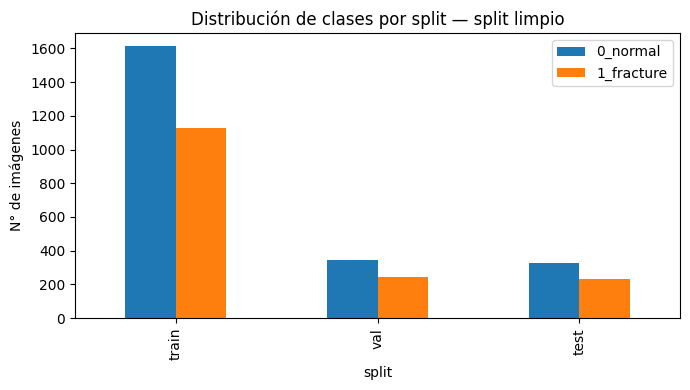

In [8]:
df_proc = counts_table(PROC)
print("Split LIMPIO (data/processed):")
display(df_proc)

# Verificación de no-fuga sobre el split limpio
split_of = defaultdict(set)
for s in SPLITS:
    for c in CLASSES:
        for p in list_images(PROC / s / c):
            split_of[hashlib.md5(p.read_bytes()).hexdigest()].add(s)
fuga = sum(1 for v in split_of.values() if len(v) > 1)
print(f"\nHashes presentes en >1 split: {fuga}  ->", "OK, sin fuga" if fuga == 0 else "REVISAR")

ax = df_proc.loc[CLASSES, SPLITS].T.plot(kind="bar", figsize=(7, 4))
ax.set_title("Distribución de clases por split — split limpio")
ax.set_ylabel("N° de imágenes"); ax.set_xlabel("split")
plt.tight_layout(); plt.savefig(FIGS / "distribucion_clases_limpio.png", dpi=120, bbox_inches="tight"); plt.show()

**Resultado (valores reales):** dataset limpio de **3 888 imágenes únicas**:

| split | 0_normal | 1_fracture | total |
|---|---|---|---|
| train | 1611 | 1127 | 2738 |
| val   | 343  | 244  | 587  |
| test  | 328  | 235  | 563  |

- Balance global ≈ **59% normal / 41% fractura** → usaremos `class_weight` en Fase 2.
- **0 hashes** compartidos entre splits → evaluación honesta.

## 5 · Muestra visual por clase (verificación humana)

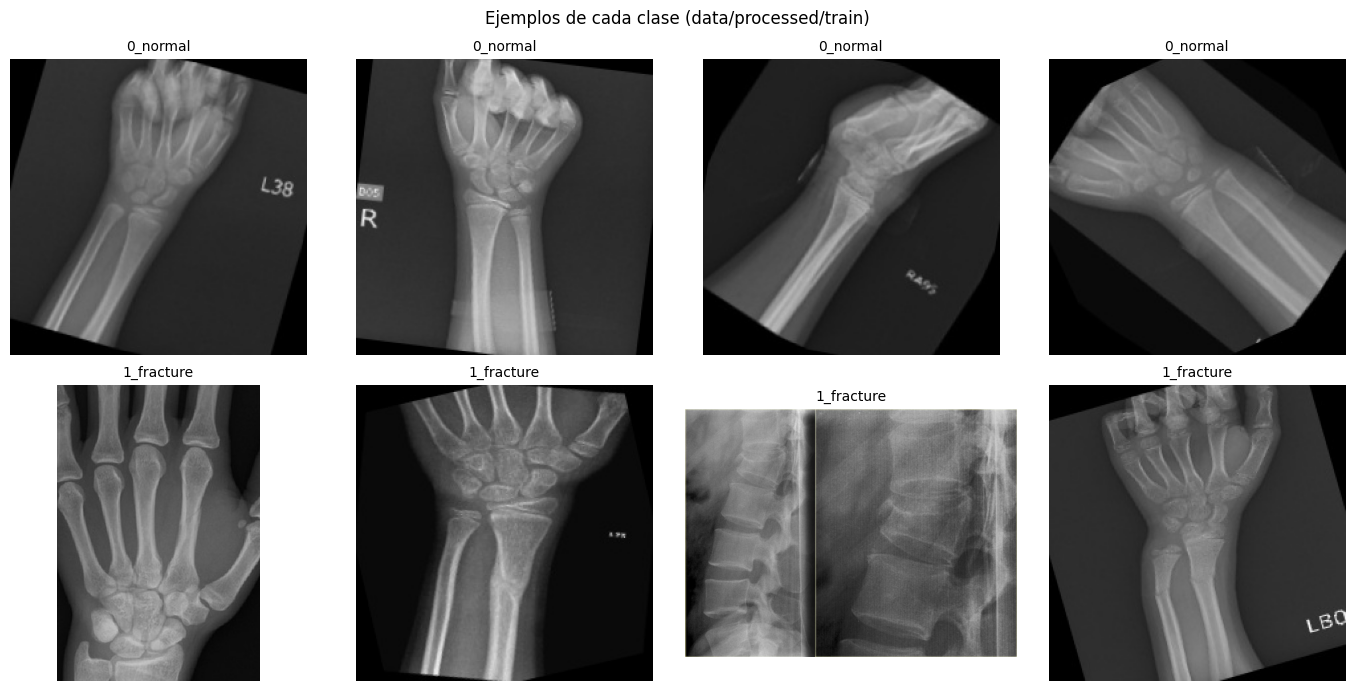

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, c in enumerate(CLASSES):
    paths = list_images(PROC / "train" / c)[:4]
    for col, p in enumerate(paths):
        with Image.open(p) as im:
            axes[row, col].imshow(im.convert("RGB"))
        axes[row, col].set_title(c, fontsize=10); axes[row, col].axis("off")
plt.suptitle("Ejemplos de cada clase (data/processed/train)")
plt.tight_layout(); plt.savefig(FIGS / "muestra_clases.png", dpi=120, bbox_inches="tight"); plt.show()

## 6 · Reflexión y decisiones para la Fase 2

- **Balance:** ~59/41 en el dataset limpio → calcular y usar `class_weight`
  (en train oficial era ~50/50; tras la limpieza el desbalance es leve y manejable).
- **Canales:** mezcla RGB/L/P/RGBA → cargar con `color_mode="rgb"`.
- **Resolución:** muy variable → redimensionar a **224×224** (tamaño estándar de
  MobileNetV2 / EfficientNetB0).
- **Duplicados y fuga:** el split oficial tenía 63% de redundancia y 873 grupos con
  fuga → **deduplicado y re-dividido sin fuga**. Esto reduce el dataset a 3 888
  imágenes, pero hace las métricas **creíbles**.
- **Sesgos / limitaciones a vigilar:**
  - El dataset mezcla varias regiones anatómicas (muñeca, hombro, rodilla…) sin
    etiqueta de región: el modelo podría aprender la región en vez de la fractura.
  - Origen muy aumentado (rotaciones) y de fuentes heterogéneas (web): posible
    sesgo de captura/equipo.
  - Una sola vista por caso, sin contexto clínico del paciente.
  - **Casi-duplicados** no exactos: mitigados por el agrupado por nombre-fuente,
    pero podría quedar algún residual (mejora opcional: hash perceptual `imagehash`).

➡️ Resultados del modelado y reflexión clínica completa en `reports/resultados.md`.